In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config

In [3]:
def compute_ke_snapshot(uvel, vvel, wvel, dx, dy, dz, rho=1000.0):
    ke = 0.5 * rho * (uvel ** 2 + vvel ** 2 + wvel ** 2) * dx * dy * dz  # This gives J per cell

    return ke / 1e6  # Convert to MJ

In [4]:
model = 'geneva_dummy_extended'
mitgcm_config, ds_to_plot = open_mitgcm_ds_from_config('..//config.json', model)

In [13]:
ds_to_plot

<xarray.Dataset> Size: 48GB
Dimensions:  (time: 336, Z: 100, YC: 132, XG: 336, YG: 132, XC: 336, Zl: 100,
              Zp1: 101, Zu: 100)
Coordinates: (12/34)
    rA       (YC, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dxG      (YG, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dyG      (YC, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    Depth    (YC, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    rAz      (YG, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dxC      (YC, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    ...       ...
  * YC       (YC) float64 1kB 50.0 150.0 250.0 ... 1.295e+04 1.305e+04 1.315e+04
  * XG       (XG) int64 3kB 0 100 200 300 400 ... 33100 33200 33300 33400 33500
  * YG       (YG) int64 1kB 0 100 200 300 400 ... 12700 12800 12900 13000 13100
  * Zp1      (Zp1) float64 808B 0.0 -0.5 -1.015 -1.546 ... -300.4 -310.1 -320.1
  * Zu       (Zu) float64 800B -0.5 -1.015 -1.546 ... -300.4 -310.1 -320.1
  * Zl       (Zl) float64 800B 0.0 -0.5 -1.015 -1.546 ... -290.9 -300.4 -310.1
Data variables:
    UVEL     (time, Z, YC, XG) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/home/leroqua...

In [7]:
grid_resolution = 200
ds_to_plot['YC'] = np.arange(1, len(ds_to_plot['YC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['XC'] = np.arange(1, len(ds_to_plot['XC'])+1) * grid_resolution - grid_resolution/2
ds_to_plot['YG'] = np.arange(0, len(ds_to_plot['YG'])) * grid_resolution
ds_to_plot['XG'] = np.arange(0, len(ds_to_plot['XG'])) * grid_resolution

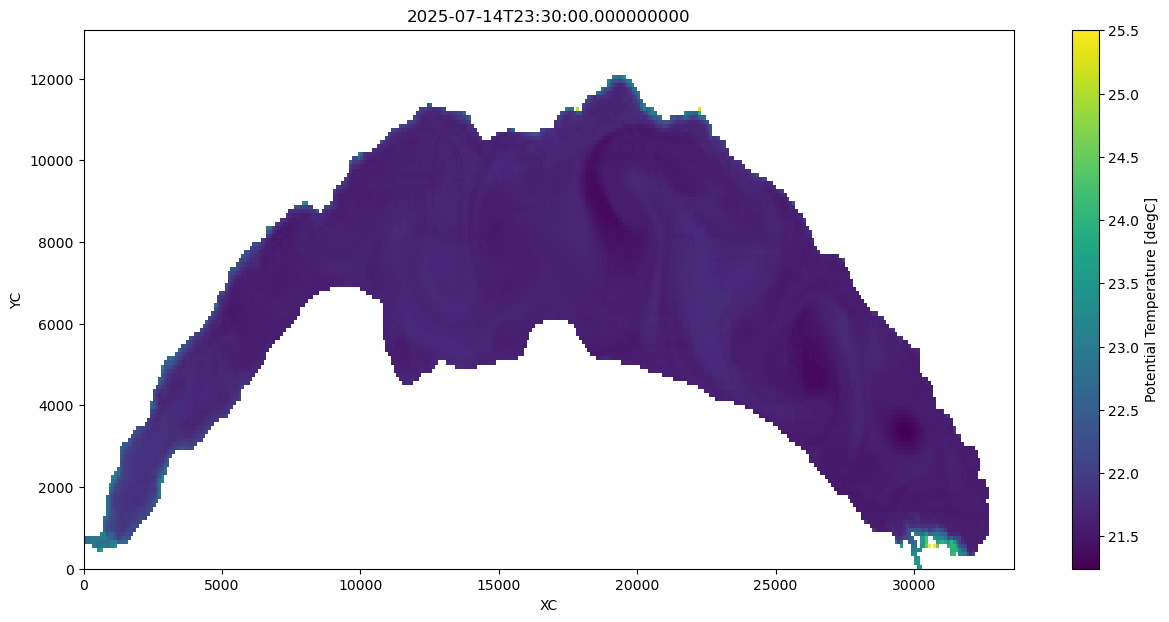

In [9]:
%matplotlib inline
t=-1
plt.close('all')
plt.figure(figsize=(15,7))
ds_sel = ds_to_plot['THETA'].isel(Z=0, time=t)
ds_sel.where(ds_sel != 0, np.nan).plot()
plt.title(ds_sel.time.values)
#plt.savefig(r"/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/dummy_extended/figures/transect_location.png")
plt.show()

In [10]:
# Compute KE per
for x_idx in range(len(ds_sel.XC)):


<xarray.Dataset> Size: 48GB
Dimensions:  (time: 336, Z: 100, YC: 132, XG: 336, YG: 132, XC: 336, Zl: 100,
              Zp1: 101, Zu: 100)
Coordinates: (12/34)
    rA       (YC, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dxG      (YG, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dyG      (YC, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    Depth    (YC, XC) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    rAz      (YG, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    dxC      (YC, XG) >f4 177kB dask.array<chunksize=(132, 336), meta=np.ndarray>
    ...       ...
  * YC       (YC) float64 1kB 50.0 150.0 250.0 ... 1.295e+04 1.305e+04 1.315e+04
  * XG       (XG) int64 3kB 0 100 200 300 400 ... 33100 33200 33300 33400 33500
  * YG       (YG) int64 1kB 0 100 200 300 400 ... 12700 12800 12900 13000 13100
  * Zp1      (Zp1) float64 808B 0.0 -0.5 -1.015 -1.546 ... -300.4 -310.1 -320.1
  * Zu       (Zu) float64 800B -0.5 -1.015 -1.546 ... -300.4 -310.1 -320.1
  * Zl       (Zl) float64 800B 0.0 -0.5 -1.015 -1.546 ... -290.9 -300.4 -310.1
Data variables:
    UVEL     (time, Z, YC, XG) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float64 12GB dask.array<chunksize=(1, 100, 132, 336), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/home/leroqua...